# Hypothesis Space II: Composable Patterns

<br>

## Learning Objectives and Lesson Structure

This notebook isolates the **hypothesis space** in the learning setup:

$$
(\mathcal{D},\mathcal{H},\mathcal{O})\mapsto s.
$$

Here $\mathcal{D}$ is the observed evidence, $\mathcal{H}$ is the set of functions available to the learner, $\mathcal{O}$ is the selection or optimisation procedure, and $s$ is the selected solution.

The core object is a set of possible realised functions:

$$
\mathcal{H}=\{h_{\theta}:\mathcal{X}\to\mathcal{Y}\mid \theta\in\Theta\}.
$$

In this notebook the examples use one-dimensional regression, so most realised functions have the form $h_{\theta}:\mathbb{R}\to\mathbb{R}$.

The central question is:

$$
\text{What behaviours become available when the hypothesis space becomes richer?}
$$

By the end, students should be able to:

- distinguish fixed features from learned features;
- explain what a single ReLU unit contributes;
- interpret a hidden layer as a sum of learned features;
- explain width as local flexibility and depth as compositional bias;
- identify how a one-dimensional MLP encodes piecewise-linear curve bias;
- distinguish expressivity from optimisation, identification, validation, and generalisation;
- explain why parameter vectors are not the same thing as hypotheses.

The notebook is organised around nine questions:

1. **What changes when features become learned?**
2. **What does one ReLU unit do?**
3. **What does a layer of ReLU units do?**
4. **What does width make available?**
5. **What does depth change?**
6. **What inductive biases does an MLP encode?**
7. **Where does $\mathcal{H}$ fill in unsupported behaviour?**
8. **What does expressivity not solve?**
9. **Why are parameters not hypotheses?**

The running visual setting is one-dimensional regression. That keeps the plots readable while $\mathcal{H}$ changes through feature maps, ReLU units, width, depth, MLP architecture, and parameterisation.

The recurring researcher-facing question is:

$$
\text{Does this hypothesis space make the behaviour we need available and defensible?}
$$


<br>

### Setup

This setup cell imports the shared plotting helpers used throughout the notebook. It changes only the Python environment for the demonstrations; each section below chooses its own editable variables, model family, and diagnostic display. Look for the same one-dimensional input range to appear while the available functions in $\mathcal{H}$ change.


In [9]:
# Environment setup. The notebook is designed to run locally and in Colab.
import os
import subprocess
import sys
import tempfile
from pathlib import Path

os.environ.setdefault(
    "MPLCONFIGDIR", str(Path(tempfile.gettempdir()) / "nextgen2026-matplotlib")
)

import matplotlib.pyplot as plt
import numpy as np
from IPython.display import display

if "google.colab" in sys.modules:
    repo_dir = Path("/content/nextgen2026-mlai-workshops")
    if not repo_dir.exists():
        subprocess.run(
            [
                "git",
                "clone",
                "--depth",
                "1",
                "--branch",
                "workshop1",
                "https://github.com/nextgenerationgraduatesprogram/nextgen2026-mlai-workshops.git",
                str(repo_dir),
            ],
            check=True,
        )
    subprocess.run([sys.executable, "-m", "pip", "install", "-q", "-e", str(repo_dir)], check=True)
    sys.path.insert(0, str(repo_dir / "src"))
else:
    for possible_root in (Path.cwd(), Path.cwd().parent):
        possible_src = possible_root / "src"
        if (possible_src / "nextgen2026_mlai_workshops").exists():
            sys.path.insert(0, str(possible_src))
            break

for module_name in list(sys.modules):
    if module_name.startswith("nextgen2026_mlai_workshops"):
        del sys.modules[module_name]

from nextgen2026_mlai_workshops.data_space import configure_matplotlib
from nextgen2026_mlai_workshops.hypothesis_space import (
    plot_capacity_demo,
    plot_depth_demo,
    plot_fixed_vs_learned,
    plot_mlp_inductive_bias_demo,
    plot_parameter_equivalence,
    plot_relu_layer,
    plot_relu_neuron,
    plot_support_model,
    plot_width_demo,
)

configure_matplotlib()

print("Setup complete. Change variables in each demo cell, then rerun that cell.")


Setup complete. Change variables in each demo cell, then rerun that cell.


<br>

## 1. What Changes When Features Become Learned?

### Motivation

A fixed-feature model can only combine features chosen in advance. Once the feature map is fixed, training selects coefficients but does not move the features themselves.

Let the feature map be:

$$
\phi:\mathcal{X}\to\mathbb{R}^{p},
\qquad
\theta\in\Theta\subseteq\mathbb{R}^{p}.
$$

The fixed-feature model is:

$$
h_{\theta}(x)=\theta^{\top}\phi(x),
$$

with hypothesis space:

$$
\mathcal{H}_{\phi}=\{x\mapsto\theta^{\top}\phi(x):\theta\in\Theta\}.
$$

Changing $\theta$ selects a different function inside $\mathcal{H}_{\phi}$. Changing $\phi$ changes the hypothesis space.

A learned ReLU feature has its own parameters:

$$
a_{w,b}(x)=\sigma(wx+b),
\qquad
\sigma(t)=\max\{0,t\}.
$$

A one-hidden-layer scalar-output ReLU model with $m$ hidden units is:

$$
h(x)=c+\sum_{j=1}^{m}v_j\sigma(w_jx+b_j),
\qquad
c,v_j,w_j,b_j\in\mathbb{R}.
$$

Now the hidden weights and biases move the intermediate representation as part of the selected function.

This section asks:

$$
\text{What changes when the feature map itself becomes parameterised?}
$$

### Minimal example

The plot compares a fixed polynomial feature map with a small learned ReLU feature map. In the polynomial panel, the learner combines $1,x,x^2,\ldots,x^d$. In the ReLU panel, hidden units create features of the form $\sigma(wx+b)$.

The editable variables let you inspect `degree`, `coefficient_preset`, `coefficient_scale`, `num_relu_features`, `kink_shift`, and `output_scale`.

Look for the difference between:

- changing coefficients inside a fixed basis;
- changing the fixed basis itself;
- moving learned ReLU features by shifting their kinks;
- adding learned features by increasing `num_relu_features`.


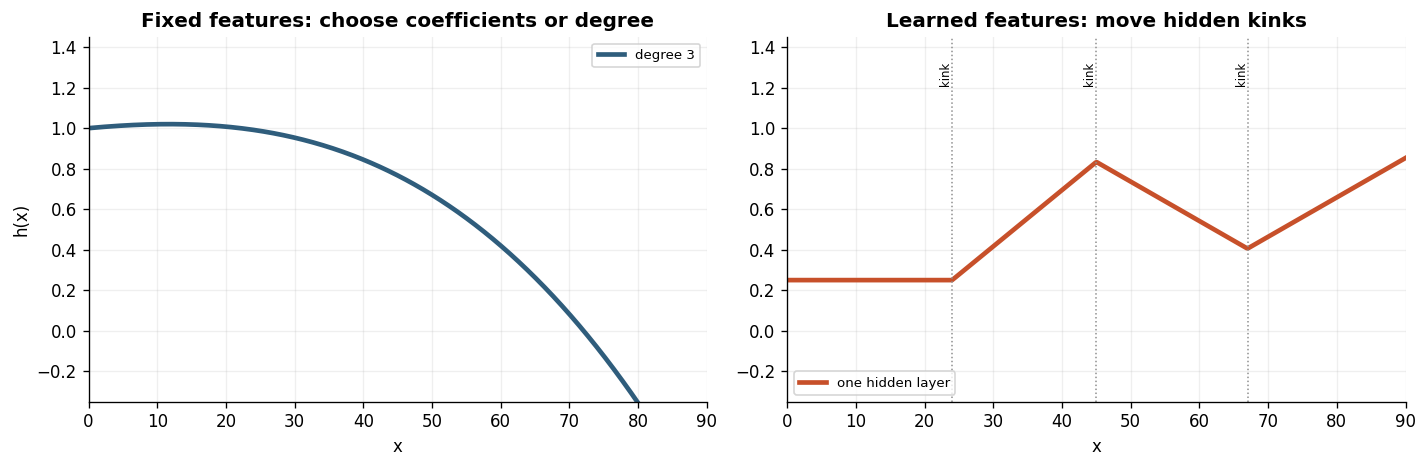

Raw polynomial coefficients theta = [ 1.000000e+00  3.120935e-03 -9.945599e-05 -1.894050e-06]
Coefficient initialisation scale = 45.0; raw x is not scaled.
ReLU feature count = 3
Raw ReLU hidden weights w = [0.055556 0.055556 0.055556]
Raw ReLU hidden biases b = [-1.333333 -2.5      -3.722222]
ReLU kink locations = [24. 45. 67.]
Raw ReLU output weights v = [ 0.5  -0.85  0.7 ], c = 0.250000
What changed: coefficients move within H; degree or ReLU feature count redefines H.
Assumption: useful features are either chosen in advance or learned as movable ReLU kinks.


In [3]:
# Change these values, then rerun this cell.
degree = 3
coefficient_preset = "smooth"      # "smooth", "oscillating", "tilted"
coefficient_scale = 45.0

num_relu_features = 3
kink_shift = 0.0
output_scale = 1.0

plot_fixed_vs_learned(
    degree=degree,
    coefficient_preset=coefficient_preset,
    coefficient_scale=coefficient_scale,
    num_relu_features=num_relu_features,
    kink_shift=kink_shift,
    output_scale=output_scale,
)


### Plot interpretation

The polynomial curve uses a fixed basis once `degree` is chosen. Coefficients select one member of $\mathcal{H}_{\phi}$; changing the degree changes the feature map and therefore changes $\mathcal{H}$.

The ReLU curve uses learned features. For unit $j$, the finite kink appears at:

$$
x_j^\star=-\frac{b_j}{w_j},
\qquad w_j\neq 0.
$$

Moving $w_j$ or $b_j$ can move the kink and change the active-side slope. The contribution of unit $j$ has slope $0$ on its inactive side and slope $v_jw_j$ on its active side.

It should be read as:

$$
\text{learned features make more behaviours available within architectural rules.}
$$

### Takeaway

The first hypothesis-space limit is **availability**.

If the relationship needed for the research claim is not available or natural in $\mathcal{H}$, optimisation cannot recover it reliably. Learning features expands what can be represented, but only within the chosen architecture.

The practical question is:

$$
\text{Is the behaviour required by the claim available and natural in }\mathcal{H}\text{?}
$$


### AI Analysis: Parameter Selection vs. Architectural Definition
- **Intra-H Movement:** Changing coefficients ($\theta, w, b, v$) moves the model *within* the current hypothesis space. This is "training" or "parameter selection."
- **H-Redefinition:** Changing the polynomial degree or the number of ReLU units (width) redefines the hypothesis space itself. This is "architectural choice."
- **Inductive Bias:** Polynomials have a global inductive bias (changes in one region affect everything), whereas ReLUs have a local inductive bias (kinks provide local adaptability).

<br>

## 2. What Does One ReLU Unit Do?

### Motivation

A single ReLU unit is one learned nonlinear feature. Its parameters determine where the feature turns on, which side is active, and how steeply it grows.

The preactivation is affine in the scalar input:

$$
z_{w,b}(x)=wx+b.
$$

The activated feature is:

$$
a_{w,b}(x)=\sigma(z_{w,b}(x))=\max\{0,wx+b\}.
$$

If $w\neq 0$, the kink occurs where the preactivation crosses zero:

$$
x^\star=-\frac{b}{w}.
$$

For $w>0$, the unit is active to the right of $x^\star$. For $w<0$, it is active to the left. If $w=0$, there is no finite kink and the feature is the constant $\max\{0,b\}$.

This section asks:

$$
\text{What does one learned feature contribute?}
$$

### Minimal example

The plot can show both the affine preactivation $z_{w,b}(x)$ and the activated ReLU feature $a_{w,b}(x)$.

The editable variables let you inspect `w`, `b`, `show_preactivation`, and `show_activation`.

Look for how:

- `b` translates the zero crossing when `w` is fixed;
- the sign of `w` flips the active side;
- the magnitude of `w` changes the active-side slope.


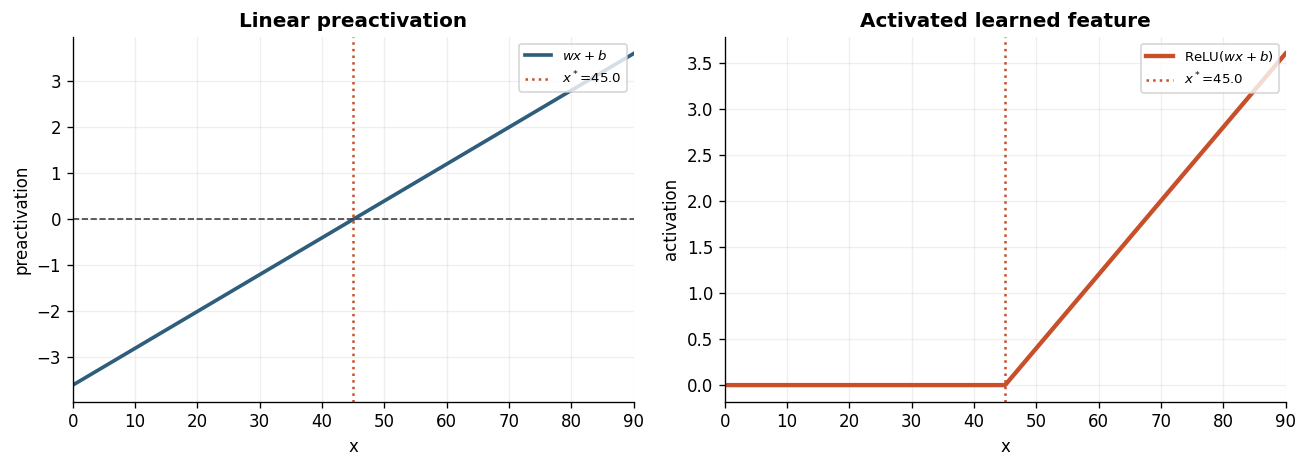

Raw ReLU weight w = 0.080000, bias b = -3.600000
kink x* = 45.00
Active side: x > 45.00
What changed: editing w or b moves the realised one-unit function within this H.
Assumption: one movable piecewise-linear change point is available.


In [4]:
# Change these values, then rerun this cell.
w = 0.08
b = -3.6
show_preactivation = True
show_activation = True

plot_relu_neuron(
    w=w,
    b=b,
    show_preactivation=show_preactivation,
    show_activation=show_activation,
)


### Plot interpretation

The preactivation panel, when shown, is $z_{w,b}(x)=wx+b$. The activation panel, when shown, is $a_{w,b}(x)=\max\{0,wx+b\}$. The ReLU clips the negative side to zero and leaves the positive side affine.

Changing `b` translates the zero crossing when `w` is fixed. Changing the sign of `w` flips which side is active. Changing the magnitude of `w` changes the active-side slope and how quickly the unit grows after it turns on.

It should be read as:

$$
\text{one ReLU unit contributes one continuous oriented hinge feature.}
$$

### Takeaway

The hypothesis-space limit here is **feature geometry**.

A single ReLU unit gives the model at most one learned change point. The location, orientation, and active-side slope of that change point are modelling degrees of freedom.

The practical question is:

$$
\text{Which local change points and orientations can one unit express?}
$$


<br>

## 3. What Does a Layer of ReLU Units Do?

### Motivation

One ReLU unit creates one learned feature. A hidden layer creates many learned features and combines them through output weights.

A width-$m$ one-hidden-layer scalar-output ReLU model is:

$$
h(x)=c+\sum_{j=1}^{m}v_j\sigma(w_jx+b_j).
$$

Each unit with $w_j\neq 0$ contributes a possible kink at:

$$
x_j^\star=-\frac{b_j}{w_j}.
$$

The output weight $v_j$ decides the sign and size of that unit's contribution. Across the active side of the kink, the slope contribution is $v_jw_j$.

This section asks:

$$
\text{How do several learned features combine into a function?}
$$

### Minimal example

The plot builds a one-hidden-layer model step by step: hidden activations, weighted contributions, and final sum.

The editable variables let you inspect `num_units`, the lists `w`, `b`, and `v`, the intercept `c`, and the display switches `show_units`, `show_weighted_units`, and `show_sum`.

Look for the difference between:

- the raw learned features $\sigma(w_jx+b_j)$;
- the weighted contributions $v_j\sigma(w_jx+b_j)$;
- the final function after all contributions are added.


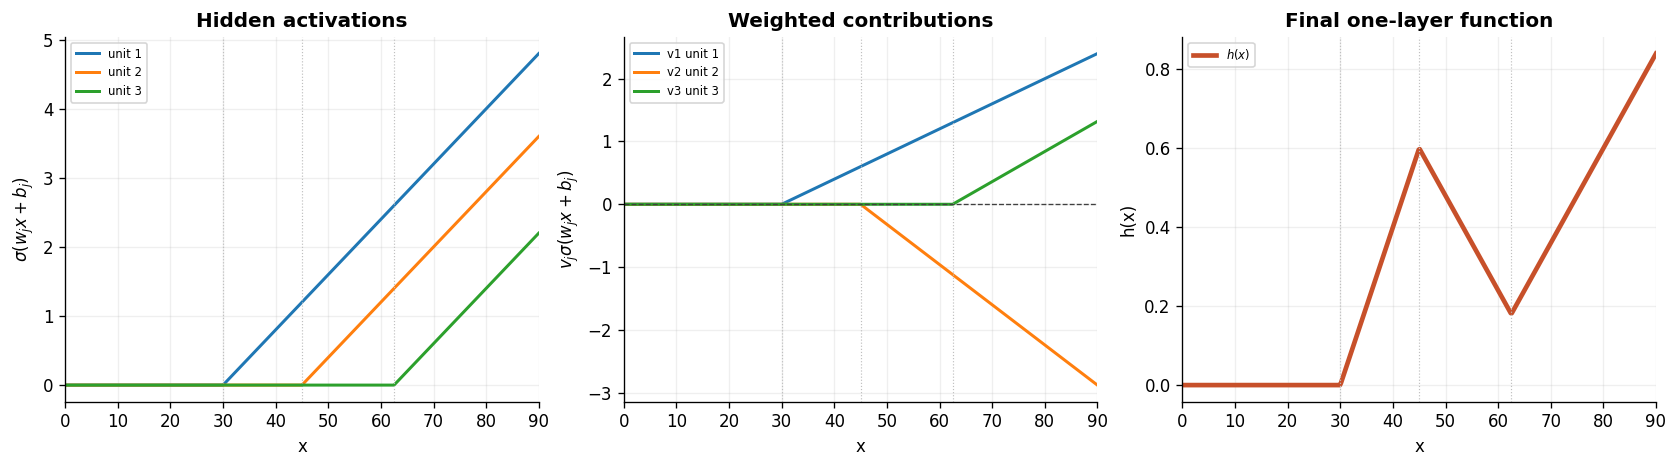

Number of units = 3, intercept c = 0.000000
Raw hidden weights w = [0.08 0.08 0.08]
Raw hidden biases b = [-2.4 -3.6 -5. ]
Raw output weights v = [ 0.5 -0.8  0.6]
Kink locations x_j* = [30.  45.  62.5]
Visible kinks in plotted domain = 3
What changed: w, b, v, and c move within this fixed-width H; num_units redefines H.
Assumption: the function is built by adding learned piecewise-linear features.


In [5]:
# Change these values, then rerun this cell.
num_units = 3
w = [0.08, 0.08, 0.08]
b = [-2.4, -3.6, -5.0]
v = [0.5, -0.8, 0.6]
c = 0.0

show_units = True
show_weighted_units = True
show_sum = True

plot_relu_layer(
    num_units=num_units,
    w=w,
    b=b,
    v=v,
    c=c,
    show_units=show_units,
    show_weighted_units=show_weighted_units,
    show_sum=show_sum,
)


### Plot interpretation

The first panel shows the learned features $\sigma(w_jx+b_j)$. The second panel shows $v_j\sigma(w_jx+b_j)$, which is what each feature contributes to the output. The final panel sums those contributions with $c$.

Adding a unit adds another available hinge. Moving `b[j]` shifts a kink when `w[j]` is nonzero. Changing `v[j]` changes the sign and magnitude of that learned feature's contribution after it turns on.

It should be read as:

$$
\text{the layer adds several learned hinge contributions into one continuous piecewise-affine function.}
$$

### Takeaway

The hypothesis-space limit here is **composition by addition**.

A ReLU layer constructs a piecewise-affine hypothesis space by adding learned hinge features. More units make more local changes available, but they also create more possible behaviours in weakly supported regions.

The practical question is:

$$
\text{Which behaviours come from adding learned features, and are those behaviours evidenced?}
$$


<br>

## 4. What Does Width Make Available?

### Motivation

The previous section showed a small layer by hand. This section varies the number of units to show how width changes available function shapes.

The width-limited one-hidden-layer scalar ReLU hypothesis space is:

$$
\mathcal{H}_m=
\left\{
 x\mapsto c+\sum_{j=1}^{m}v_j\sigma(w_jx+b_j):
 c\in\mathbb{R},\ v,w,b\in\mathbb{R}^{m}
\right\}.
$$

For scalar inputs, a function in $\mathcal{H}_m$ has at most $m$ distinct finite kink locations, because units with $w_j=0$ have no finite kink and different units can share the same kink.

Increasing $m$ changes $\mathcal{H}_m$. It is not merely selecting a different member of the same class.

This section asks:

$$
\text{What behaviours become available as width increases?}
$$

### Minimal example

The plot holds the display target fixed and changes the number and placement of ReLU units.

The editable variables let you inspect `num_units`, `parameter_preset`, `output_scale`, and `seed`.

Compare cases such as:

- `num_units = 1`;
- `num_units = 3`;
- `num_units = 8`;
- `parameter_preset = "clustered"`.

Look for whether added units create distinct local changes or concentrate flexibility in one part of the domain.


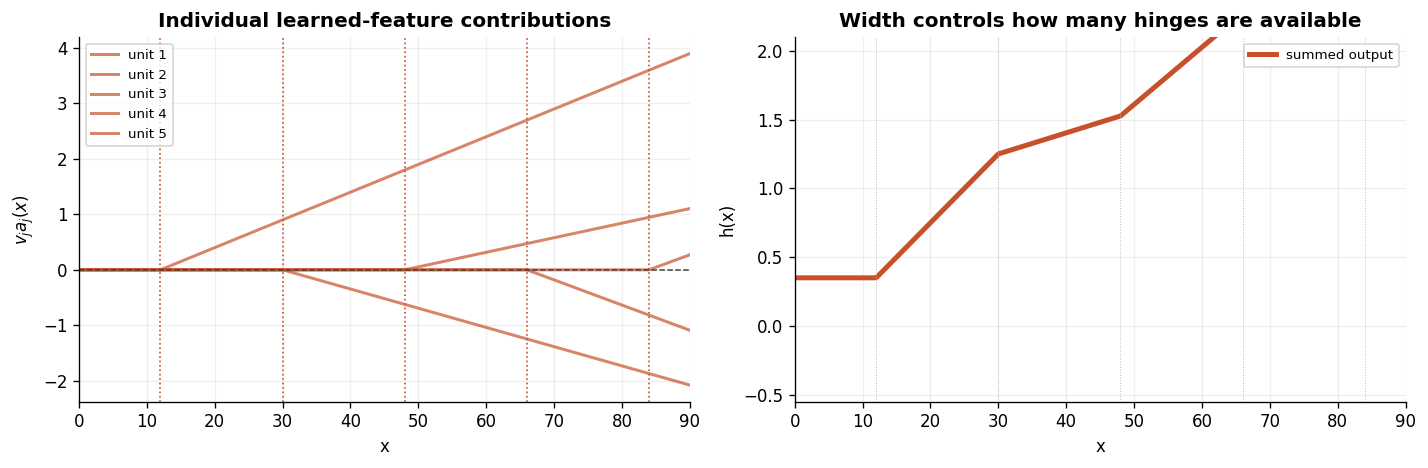

Width m = 5
Parameter preset = spread; visible kink locations = 5
Raw hidden weights w = [0.071429 0.071429 0.071429 0.071429 0.071429]
Raw hidden biases b = [-0.857143 -2.142857 -3.428571 -4.714286 -6.      ]
Kink locations = [12. 30. 48. 66. 84.]
Raw output weights v = [ 0.7      -0.48524   0.368067 -0.636071  0.631461], c = 0.350000
What changed: num_units changes H_m; preset, seed, and output_scale select a function inside that width demo.
Assumption: width makes more local piecewise-linear changes available.


In [6]:
# Change these values, then rerun this cell.
num_units = 5
parameter_preset = "spread"      # "spread", "clustered", "random"
output_scale = 1.0
seed = 0

plot_width_demo(
    num_units=num_units,
    parameter_preset=parameter_preset,
    output_scale=output_scale,
    seed=seed,
)


### Plot interpretation

The component plot shows how many local ReLU contributions are available. The final plot shows their sum. The printed diagnostics count visible kink locations in the plotted domain and report whether the units were spread, clustered, or random.

Width controls how many hinge features can be placed into the function. It does not decide which hinges are supported by the data.

It should be read as:

$$
\text{more width gives the selected function more local degrees of freedom.}
$$

### Takeaway

The hypothesis-space limit here is **local flexibility**.

Width can reduce approximation error by making more local behaviours available. It does not decide which local behaviours are identified by observations, validated out of sample, or relevant to the claim.

The practical question is:

$$
\text{Where does added width create useful flexibility, and where does it create unsupported freedom?}
$$


### AI Analysis: Capacity, Overfitting, and Generalization
- **Interpolation Capacity:** As $H$ grows (more parameters, higher degree, more units), it gains the ability to "connect the dots" perfectly, matching the training data noise.
- **Run-off and Oscillation:** High-capacity models without proper constraints (regularization) often exhibit wild oscillations in unsupported regions or extreme run-off at the boundaries.
- **The "Truth" Trap:** A model that matches training points perfectly is often *less* truthful regarding the underlying physical process than a simpler, slightly underfitting model.

<br>

## 5. What Does Depth Change?

### Motivation

Width adds features in parallel. Depth composes transformations. Later layers can reuse and recombine earlier features.

Using the standard column-vector convention, an MLP with $L-1$ hidden layers can be written as:

$$
a^{(0)}=x,
$$

$$
z^{(\ell)}=W^{(\ell)}a^{(\ell-1)}+b^{(\ell)},
\qquad
\ell=1,\ldots,L-1,
$$

$$
a^{(\ell)}=\sigma(z^{(\ell)}),
\qquad
\ell=1,\ldots,L-1,
$$

and the scalar output is:

$$
h_{\theta}(x)=W^{(L)}a^{(L-1)}+b^{(L)}.
$$

Here $\sigma$ is applied coordinatewise. If $a^{(\ell)}\in\mathbb{R}^{d_{\ell}}$, then $W^{(\ell)}\in\mathbb{R}^{d_{\ell}\times d_{\ell-1}}$ and $b^{(\ell)}\in\mathbb{R}^{d_{\ell}}$ for hidden layers, while $W^{(L)}\in\mathbb{R}^{1\times d_{L-1}}$ and $b^{(L)}\in\mathbb{R}$ for scalar regression.

Equivalently, the realised function is a composition:

$$
h_{\theta}=g_L\circ g_{L-1}\circ\cdots\circ g_1.
$$

The Python helper stores batches as row arrays and computes `a @ W + b`, so printed matrix shapes are transposed relative to the column-vector equations above. The represented MLP is the same.

This section asks:

$$
\text{What changes when learned features are composed?}
$$

### Minimal example

The plot shows intermediate layer outputs and the final output for a small network. In the code cell, `depth` controls the number of hidden transformations shown.

The editable variables let you inspect `depth`, `width`, `activation`, `seed`, `show_layer_outputs`, and `show_final_output`.

Compare cases such as:

- `depth = 1`, `depth = 2`, and `depth = 3`;
- `width = 2` and `width = 6`;
- different `seed` values.

Look for how later layers reuse earlier features rather than adding independent hinges directly to the input.


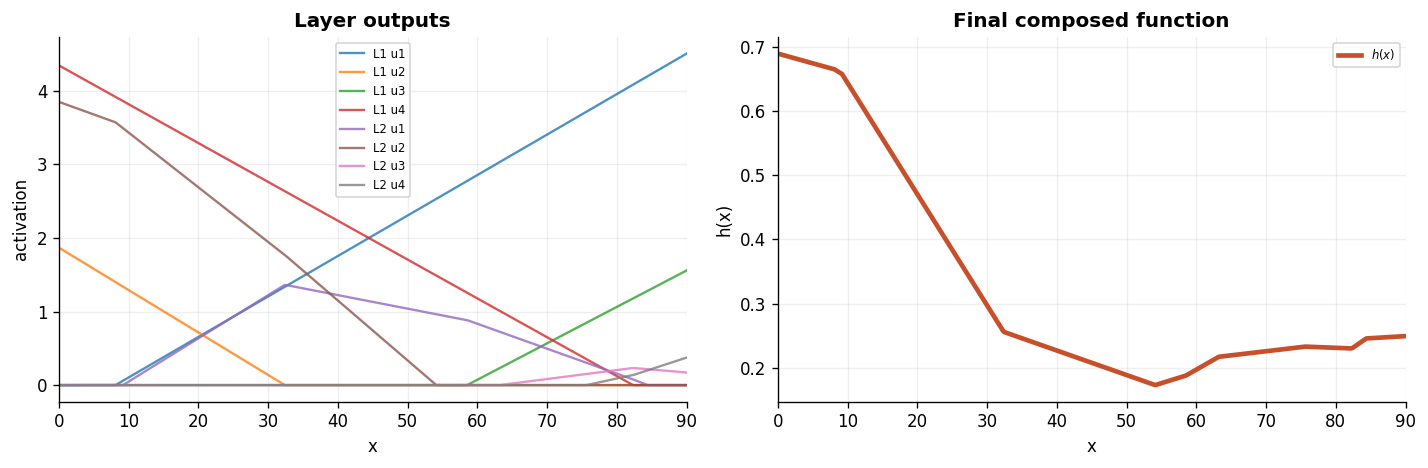

Depth = 2, width = 4, activation = relu, seed = 0
Approximate visible linear regions = 6
First-layer W shape = (1, 4), b shape = (4,)
Output weights = [-0.18309  0.08808 -0.40385 -0.08367], output bias = 0.35000
What changed: depth, width, and activation redefine H; seed selects one parameter point inside it.
Assumption: useful functions can be built by composing and reusing intermediate features.


In [17]:
# Change these values, then rerun this cell.
depth = 2
width = 4
activation = "relu"
seed = 0

show_layer_outputs = True
show_final_output = True

plot_depth_demo(
    depth=depth,
    width=width,
    activation=activation,
    seed=seed,
    show_layer_outputs=show_layer_outputs,
    show_final_output=show_final_output,
)


### Plot interpretation

The layer-output panel shows intermediate activations $a^{(\ell)}$. The final-output panel shows the composed function after those activations have been reused and recombined.

For ReLU networks, each fixed activation pattern defines a region of input space where the network is affine. The approximate linear-region count is a diagnostic, not a theorem, but it helps connect visible bends to composition.

It should be read as:

$$
\text{depth changes how functions are built from composed representations.}
$$

### Takeaway

The hypothesis-space limit here is **compositional bias**.

Depth can make some functions efficient to represent and others awkward. It changes which behaviours are natural in $\mathcal{H}$, not just how many parameters the model contains.

The practical question is:

$$
\text{Does the claim require a relationship that is naturally represented by composition?}
$$


### AI Analysis: Activation Functions - ReLU
- **ReLU (Rectified Linear Unit):** The current standard in deep learning. It creates "sharp" kinks by zeroing out negative values ($f(x) = \max(0, x)$).
- **Inductive Bias:** Results in a **piecewise-linear** function. This is mathematically efficient and avoids the "vanishing gradient" problem found in smooth activations, allowing for much deeper networks.
- **Visual:** Notice the sharp corners in the layer outputs and the final aggregated curve.

### AI Analysis: Activation Functions - Tanh
- **Tanh (Hyperbolic Tangent):** A smooth, S-shaped activation that maps inputs to the range $(-1, 1)$.
- **Inductive Bias:** Produces a **smooth, differentiable** output. While aesthetically pleasing and representative of some natural saturation processes, it can be harder to train in deep networks because the gradients become very small ("vanish") as the output approaches $1$ or $-1$.
- **Visual:** Compare the smooth transitions here to the sharp kinks of the ReLU.

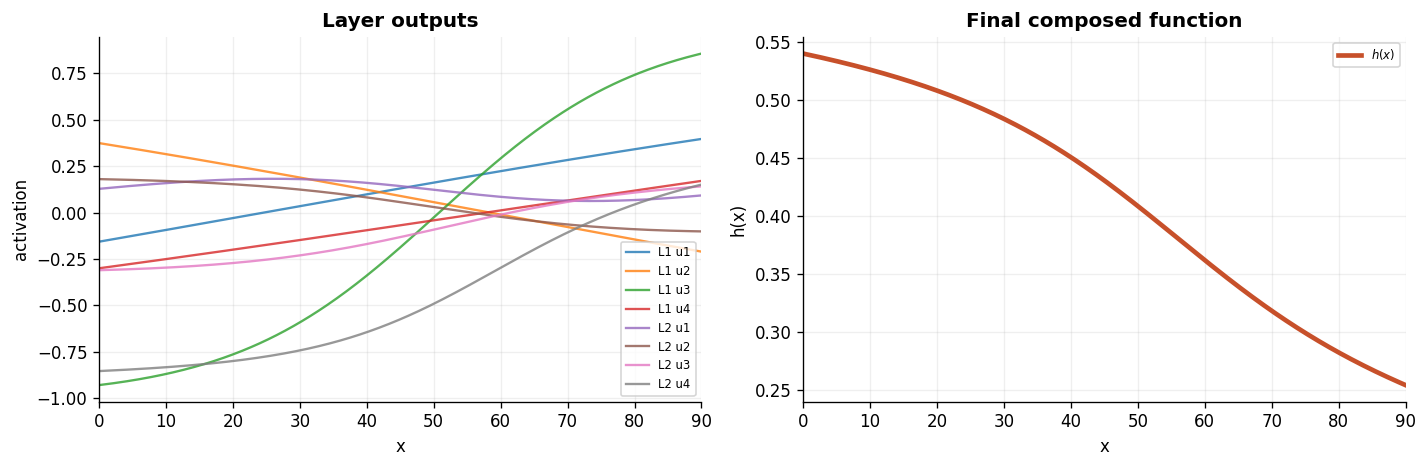

Depth = 2, width = 4, activation = tanh, seed = 0
Approximate visible linear regions = 1
First-layer W shape = (1, 4), b shape = (4,)
Output weights = [-0.18309  0.08808 -0.40385 -0.08367], output bias = 0.35000
What changed: depth, width, and activation redefine H; seed selects one parameter point inside it.
Assumption: useful functions can be built by composing and reusing intermediate features.


In [18]:
# DEMO: Smooth activation with Tanh
depth = 2
width = 4
activation = "tanh"
seed = 0

plot_depth_demo(
    depth=depth,
    width=width,
    activation=activation,
    seed=seed,
    show_layer_outputs=True,
    show_final_output=True,
)


### AI Analysis: Activation Functions - Linear
- **Linear Activation:** Effectively "no activation" ($f(x) = x$).
- **The Composition Limit:** Composing multiple linear layers results in a single linear transformation. Mathematically: $W_2(W_1x + b_1) + b_2 = (W_2W_1)x + (W_2b_1 + b_2)$. 
- **Inductive Bias:** Depth with linear activation adds **zero expressivity**. No matter how many layers you add, the hypothesis space is still just a simple line.
- **Visual:** Notice that the output is a perfectly straight line, despite having multiple hidden layers.

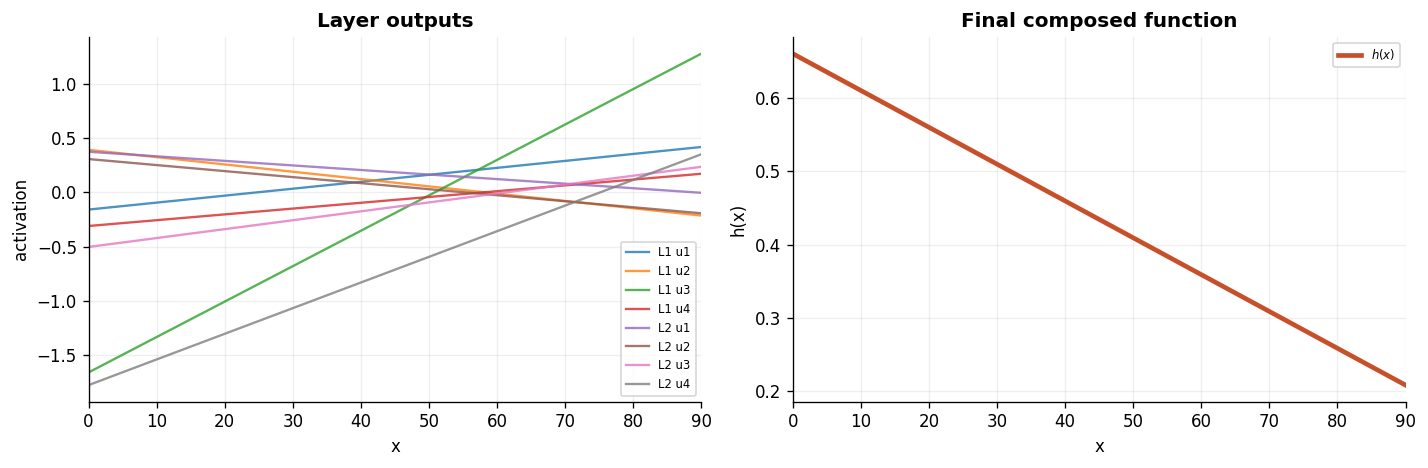

Depth = 2, width = 4, activation = linear, seed = 0
Approximate visible linear regions = 1
First-layer W shape = (1, 4), b shape = (4,)
Output weights = [-0.18309  0.08808 -0.40385 -0.08367], output bias = 0.35000
What changed: depth, width, and activation redefine H; seed selects one parameter point inside it.
Assumption: useful functions can be built by composing and reusing intermediate features.


In [19]:
# DEMO: The limit of Linear composition
depth = 2
width = 4
activation = "linear"
seed = 0

plot_depth_demo(
    depth=depth,
    width=width,
    activation=activation,
    seed=seed,
    show_layer_outputs=True,
    show_final_output=True,
)


<br>

## 6. What Inductive Biases Does an MLP Encode?

### Motivation

An MLP is flexible, but it is not assumption-free. In this notebook the input is one-dimensional:

$$
x=\text{observed tilt}.
$$

So the important bias is not how an MLP mixes many input coordinates. There is only one input coordinate. The important question is what kinds of curves an MLP naturally builds over $x$.

For a ReLU MLP, the basic unit is a hinge:

$$
\sigma(wx+b)=\max(0,wx+b).
$$

This unit is flat on one side of a threshold and linear on the other. A one-hidden-layer ReLU MLP is:

$$
h_{\theta}(x)
=
b_2+\sum_{j=1}^{m}v_j\sigma(w_jx+b_j).
$$

Each hidden unit can introduce a change in slope at:

$$
x_j^\star=-\frac{b_j}{w_j},
\qquad
w_j\neq 0.
$$

So, in one dimension, a ReLU MLP builds a continuous piecewise-linear curve. Width gives the model more possible slope changes. Depth composes these transformations and can create more complex piecewise-linear structure.

This is a powerful bias, but it is still a bias. The MLP does not automatically know that the true physical response is smooth, non-negative, monotone, periodic, or that the narrow region near $x=65$ matters. Those behaviours must be learned from data or encouraged by the training procedure.

This section asks:

$$
\text{What behaviours does the MLP make easy, and what behaviours must be learned from evidence?}
$$

### Minimal example

The plot compares MLP functions on the same one-dimensional regression task.

The editable variables should include:

```python
width = 16
depth = 2
activation = "relu"
seed = 0
weight_scale = 1.0
weight_decay = 1e-4
epochs = 300
show_kinks = True
```

Look for:

- where the fitted MLP follows the observed data;
- whether the narrow feature near $x=65$ is captured;
- how ReLU slope-change diagnostics move as `width`, `depth`, and `seed` change;
- how stronger `weight_decay` prefers lower-norm, less rapidly varying curves.


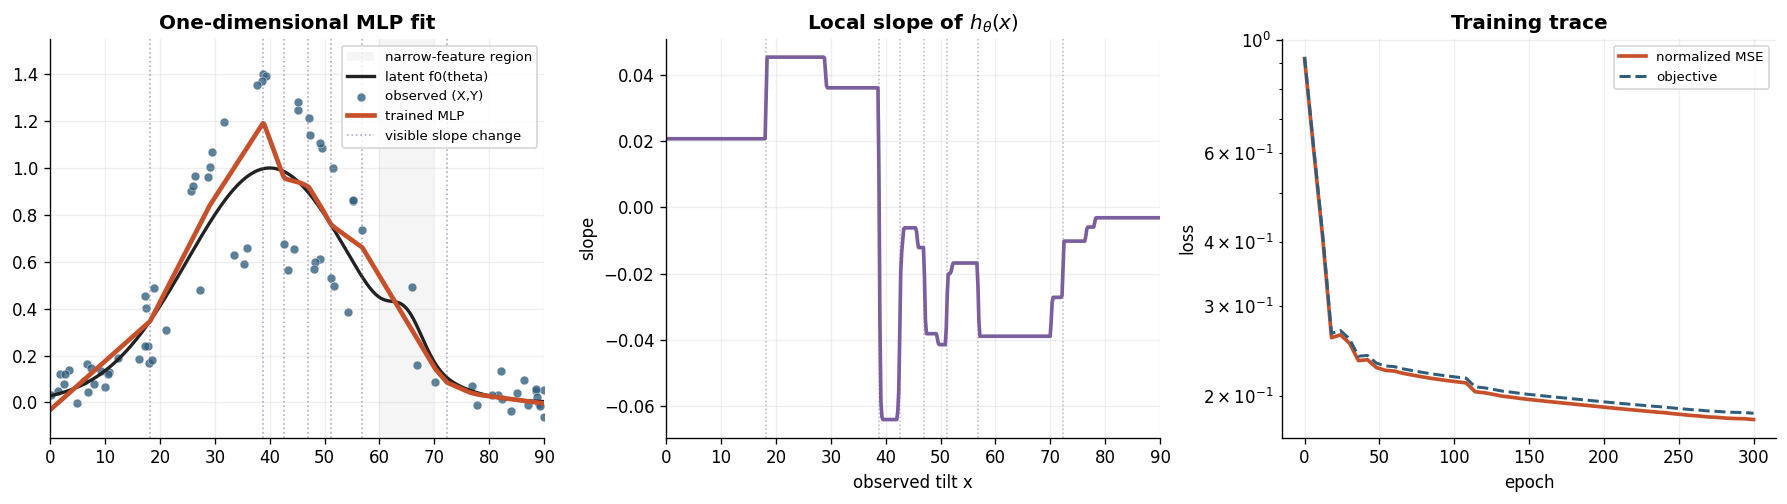

MLP inductive-bias demo
Depth = 2, width = 16, activation = relu, weight_scale = 1.000, weight_decay = 0.0001
Seed = 0, epochs = 300
Training MSE = 0.03503; oracle grid MSE = 0.00337
Approximate visible linear regions = 18
Visible slope-change locations in raw x = [18.216 38.778 42.565 47.074 51.222 56.814 72.325]
First-layer implementation matrix shape (input_dim, width) = (1, 16)
What changed: width and depth redefine H_MLP; seed and weight_scale choose an initial parameter point; weight_decay and epochs change O.
Assumption: the target curve is learnable as a continuous piecewise-linear function of observed tilt.
Solution bias: weight decay and optimisation tend to prefer lower-norm, less rapidly varying realised functions.


In [20]:
# Change these values, then rerun this cell.
width = 16
depth = 2
activation = "relu"
seed = 0
weight_scale = 1.0
weight_decay = 1e-4
epochs = 300
show_kinks = True

plot_mlp_inductive_bias_demo(
    width=width,
    depth=depth,
    activation=activation,
    seed=seed,
    weight_scale=weight_scale,
    weight_decay=weight_decay,
    epochs=epochs,
    show_kinks=show_kinks,
)


### Plot interpretation

Read the plot as a diagnostic for the curve bias of a one-dimensional MLP. The first panel shows the observed data, the latent reference curve, and the trained MLP function. The second panel shows the local slope of the fitted function. The third panel shows the training trace.

For `activation = "relu"`, the fitted curve is continuous and piecewise-linear. If `depth = 1`, dotted lines mark exact first-layer thresholds that can create slope changes. If `depth > 1`, dotted lines mark visible slope-change locations in the realised curve, because deeper compositions can create additional breakpoints.

The plot can show flexibility, but it does not show that the MLP knows the physics. Smoothness, non-negativity, monotonicity, periodicity, and attention to the narrow feature near $x=65$ must come from evidence, regularisation, optimisation, or a more structured hypothesis space.

It should be read as:

$$
\text{a ReLU MLP makes continuous piecewise-linear curves easy, but physical shape constraints remain data-dependent.}
$$

### Takeaway

The hypothesis-space limit here is **piecewise-linear curve bias**.

A one-dimensional ReLU MLP naturally builds continuous piecewise-linear functions. Width makes more slope changes available, depth composes slope changes, and optimisation plus regularisation select one realised curve from that space.

The practical question is:

$$
\text{Does this MLP bias match the physical behaviour the research claim needs?}
$$


### AI Analysis: Controlling MLP Bias
- **The "Sum of Hinges" Frame:** By viewing the output as $b_2 + \sum v_j \sigma(w_j x + b_j)$, we see that the MLP's "complexity" is directly tied to the number of active hidden units ($v_j \neq 0$).
- **Weight Decay as Complexity Control:** `weight_decay` (L2 regularization) pushes the weights ($w_j, v_j$) towards zero. In this framework, it acts as a "simplicity bias," forcing the model to explain the data with fewer active or less "sharp" hinges, which results in smoother curves.
- **Learned Resolution:** The model doesn't have a fixed resolution. It "allocates" its limited number of hinges (kinks) to regions where the gradient of the loss is highest. If the data density is low near a feature, the MLP will likely "spend" its hinges elsewhere, effectively ignoring the feature.
- **Active Biases:** By "framing the output" through regularization and architecture, we aren't just fitting data; we are selecting which mathematical properties (smoothness, norm, piecewise-linearity) we want to dominate the solution.

### AI Analysis: Width vs. Depth - The Layered Bias
- **Feature Composition:** While "width" adds more simple features in parallel, "depth" allows the model to compose these features, creating hierarchical representations. 
- **The "Broken Line" Effect:** In deep networks with ReLUs, the output is a continuous piecewise-linear function where the number of possible "kinks" (linear regions) grows exponentially with depth, not just linearly with width.
- **Architectural Selection:** Deep architectures often generalize better because they favor functions that can be decomposed into simpler nested sub-functions, matching the hierarchical structure of many physical processes.

<br>

## 7. Where Does $\mathcal{H}$ Fill In Unsupported Behaviour?

### Motivation

The data-space notebook asked where the dataset provides evidence. This section asks what the hypothesis space does where evidence is weak or absent.

The empirical risk only evaluates observed samples:

$$
\widehat{R}_{\mathcal{D}}(h)=
\frac{1}{n}\sum_{i=1}^{n}\ell(h(x_i),y_i).
$$

Two functions can have similar empirical risk while disagreeing away from observed inputs. In a gap, the plotted continuation comes from $\mathcal{H}$ and $\mathcal{O}$ as much as from $\mathcal{D}$.

This section asks:

$$
\text{How does }\mathcal{H}\text{ fill gaps left by }\mathcal{D}\text{?}
$$

### Minimal example

The plot uses a fixed regression dataset with a deliberate gap near a narrow feature. Hold the dataset fixed when `seed` is fixed, then change only the model family or complexity.

The editable variables let you inspect `model_kind`, `complexity`, `lam`, `period`, and `seed`.

Look for the difference between:

- observed regions where $\mathcal{D}$ constrains the fit;
- the shaded gap where the model must still output something;
- different continuations produced by different choices of $\mathcal{H}$.


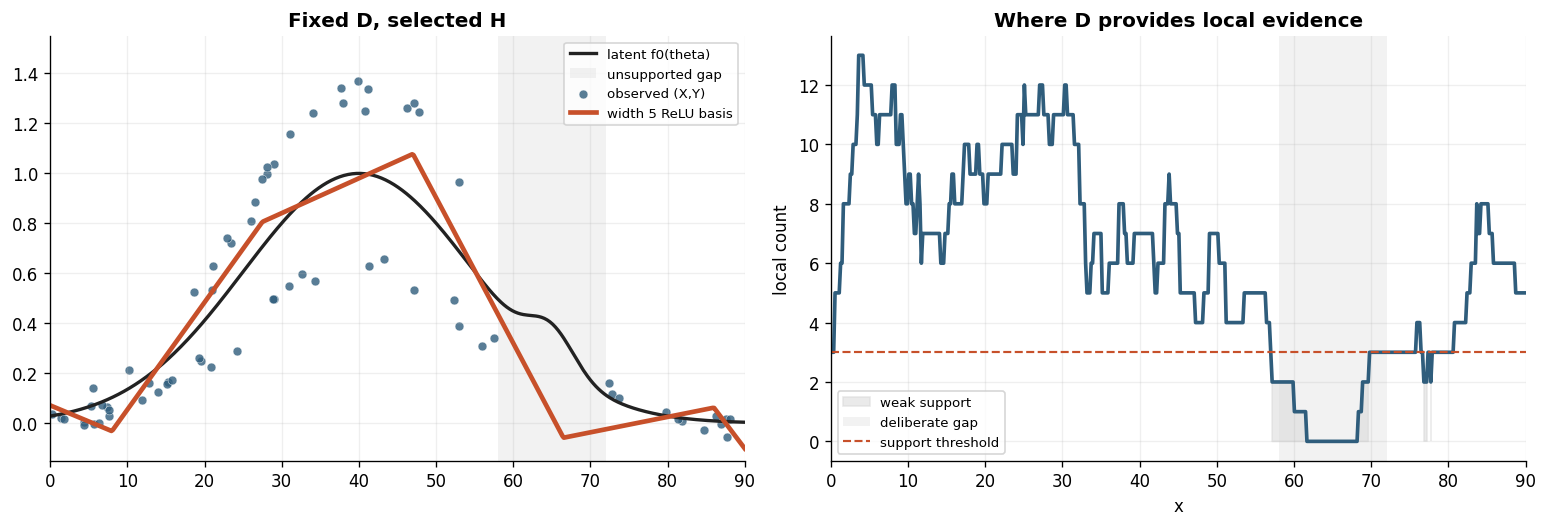

Hypothesis class: width 5 ReLU basis
Assumption outside support: piecewise-linear continuation
Fitted raw-basis coefficients = [ 0.071407 -0.012894  0.05586  -0.029028 -0.072199  0.064433 -0.04712 ]
Errors: train=0.0439, observed-oracle=0.0055, gap-oracle=0.0698
What changed: model_kind and complexity redefine H; lam changes O; seed changes D.
Assumption: unsupported gap behaviour is supplied by the selected basis and penalty.


In [10]:
# Change these values, then rerun this cell.
model_kind = "relu"       # "poly", "relu", "periodic"
complexity = 5
lam = 1e-3
period = 90.0
seed = 0

plot_support_model(
    model_kind=model_kind,
    complexity=complexity,
    lam=lam,
    period=period,
    seed=seed,
)


### Plot interpretation

The observed data and shaded gap show where $\mathcal{D}$ provides evidence. The fitted curve shows what the selected $\mathcal{H}$ and $\mathcal{O}$ do anyway.

The true curve and gap-region error are teaching diagnostics only. In ordinary research settings, the true response in the unsupported gap is not observed.

It should be read as:

$$
\text{the fitted continuation is a hypothesis-space and optimisation choice in the gap.}
$$

### Takeaway

The hypothesis-space limit here is **unsupported continuation**.

A model always outputs something. That output is not always evidence. In unsupported regions, the answer comes from $\mathcal{H}$ and $\mathcal{O}$ as much as from $\mathcal{D}$.

The practical question is:

$$
\text{Where is the model continuing beyond the support of the evidence?}
$$


<br>

## 8. What Does Expressivity Not Solve?

### Motivation

A richer hypothesis space can represent more functions. That is useful, but expressivity is only one part of the learning problem.

Expressivity asks whether the target can be represented inside $\mathcal{H}$:

$$
\inf_{h\in\mathcal{H}}R(h),
\qquad
R(h)=\mathbb{E}_{(X,Y)\sim P}[\ell(h(X),Y)].
$$

Optimisation asks whether training finds a good parameter vector:

$$
\widehat{\theta}\approx
\arg\min_{\theta\in\Theta}
\widehat{R}_{\mathcal{D}}(h_{\theta}).
$$

Identification asks whether finite data distinguish plausible functions:

$$
h_1(x_i)=h_2(x_i)\ \forall i
\quad\not\Rightarrow\quad
h_1(x)=h_2(x)\ \forall x.
$$

Generalisation asks whether empirical performance transfers to new data:

$$
R(\widehat{h})-\widehat{R}_{\mathcal{D}}(\widehat{h}).
$$

This section asks:

$$
\text{Why is being able to represent a function not enough?}
$$

### Minimal example

The plot uses a capacity demonstration with a fixed dataset. Compare training error, validation error, and oracle/grid error as capacity increases. Then set `label_mode = "random"` to check whether low training error alone can support a research claim.

The editable variables let you inspect `capacity`, `noise_level`, `label_mode`, `train_size`, and `seed`.

Look for the difference between:

- lower training error;
- validation or oracle error that stops improving;
- random-label fits that do not indicate a stable relationship.


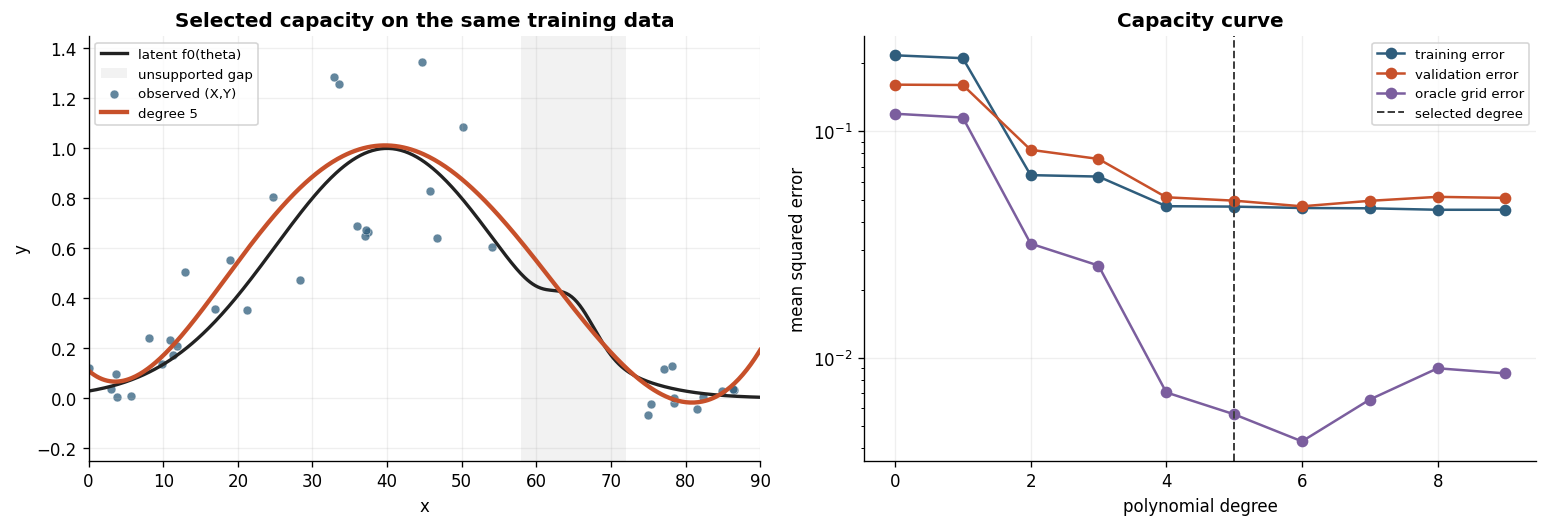

Selected training MSE = 0.0466
Capacity = 5, label_mode = true, noise_level = 0.100
Train size = 40, seed = 0
What changed: capacity changes H; label_mode, noise_level, train_size, and seed change D.
Assumption: expressivity alone does not identify, optimise, or validate the selected function.


In [13]:
# Change these values, then rerun this cell.
capacity = 5
noise_level = 0.1
label_mode = "true"       # "true", "random"
train_size = 40
seed = 0

plot_capacity_demo(
    capacity=capacity,
    noise_level=noise_level,
    label_mode=label_mode,
    train_size=train_size,
    seed=seed,
)


### Plot interpretation

Training error can improve as capacity increases even when validation error or oracle error does not. With random labels, fitting the observations is possible even when there is no stable relationship to recover.

This plot separates four questions: what $\mathcal{H}$ can represent, what $\mathcal{O}$ selects, what finite $\mathcal{D}$ identifies, and what transfers to new data.

It should be read as:

$$
\text{expressivity still needs selection, identification, and validation.}
$$

### Takeaway

The hypothesis-space limit here is **selection and validation**.

Expressivity is necessary only when the target function is otherwise unavailable. It does not replace evidence, optimisation, identification, or validation.

The practical question is:

$$
\text{What evidence shows that the selected expressive function is the right one?}
$$


<br>

## 9. Why Are Parameters Not Hypotheses?

### Motivation

Optimisation moves through parameter space, but predictions are made by realised functions. Different parameter vectors can represent the same function.

The parameter vector $\theta$ lives in parameter space $\Theta$. The realised function $h_{\theta}$ lives in hypothesis space $\mathcal{H}$.

The map is:

$$
q:\Theta\rightarrow\mathcal{H},
\qquad
q(\theta)=h_{\theta}.
$$

This map need not be one-to-one. The hypothesis space is the image $q(\Theta)$, not the parameter space itself.

For a one-hidden-layer network:

$$
h(x)=c+\sum_{j=1}^{m}v_j\sigma(w_jx+b_j).
$$

Permuting hidden units leaves the function unchanged. For any permutation $\pi$ of $\{1,\ldots,m\}$:

$$
\sum_{j=1}^{m}v_j\sigma(w_jx+b_j)
=
\sum_{j=1}^{m}v_{\pi(j)}\sigma(w_{\pi(j)}x+b_{\pi(j)}).
$$

ReLU also has positive homogeneity:

$$
\sigma(\alpha t)=\alpha\sigma(t),
\qquad
\alpha>0.
$$

Therefore each hidden unit can be positively rescaled without changing the realised function:

$$
v_j\sigma(w_jx+b_j)
=
\frac{v_j}{\alpha_j}\sigma(\alpha_j w_jx+\alpha_j b_j),
\qquad
\alpha_j>0.
$$

This section asks:

$$
\text{Why should we distinguish parameter space from hypothesis space?}
$$

### Minimal example

The plot compares an original parameter vector with a transformed one that should realise the same function.

The editable variables let you inspect `transform`, `alpha`, and `seed`.

Look for whether:

- permuting hidden units changes the realised function;
- positive rescaling changes the realised function;
- parameter movement is visible in function space.


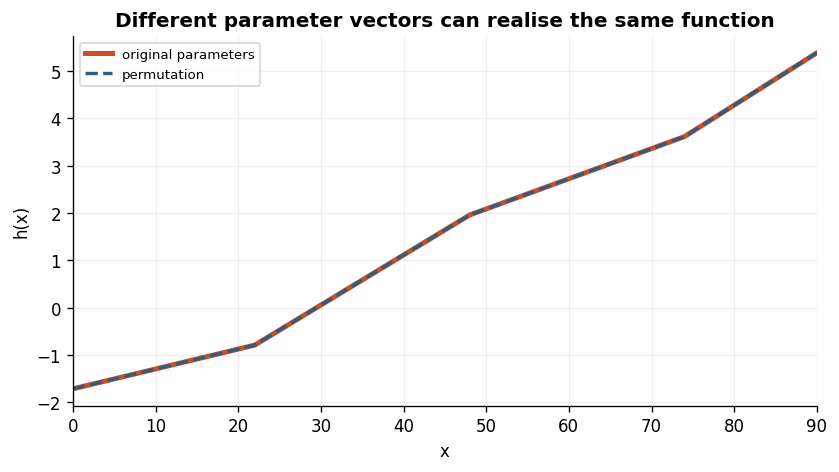

Transform = permutation, alpha = 2.000000, seed = 0
Original w = [ 0.075 -0.06   0.085]
Original b = [-1.65  2.88 -6.29]
Original v = [ 0.85 -0.7   0.55], c = 0.300000
Transformed w = [ 0.085  0.075 -0.06 ]
Transformed b = [-6.29 -1.65  2.88]
Transformed v = [ 0.55  0.85 -0.7 ], c = 0.300000
Max |h_original(x) - h_transformed(x)| = 0.000e+00
What changed: parameters changed, but the realised function stayed in the same point of H.
Assumption: scientific claims should target function behaviour, not arbitrary coordinates.


In [12]:
# Change these values, then rerun this cell.
transform = "permute"      # "permute", "positive_rescale"
alpha = 2.0
seed = 0

plot_parameter_equivalence(
    transform=transform,
    alpha=alpha,
    seed=seed,
)


### Plot interpretation

The original and transformed parameter vectors should draw the same realised function up to numerical precision. The difference curve is summarised by the maximum absolute function difference printed below the plot.

Parameter movement is therefore not automatically scientifically meaningful. A research claim usually concerns how $h_{\theta}$ behaves, not which arbitrary coordinate vector represents it.

It should be read as:

$$
\text{the same realised function can have multiple parameter representations.}
$$

### Takeaway

The hypothesis-space limit here is **representation redundancy**.

Parameter movement is not automatically scientifically meaningful because $q:\Theta\to\mathcal{H}$ is generally not injective. Research claims usually concern function behaviour, not arbitrary parameter coordinates.

The practical question is:

$$
\text{Is the claim about the realised function or about a non-identifiable parameter coordinate?}
$$


### AI Analysis: Inductive Bias and Extrapolation
- **Behavior Beyond Data:** Every model has an "extrapolation profile" determined by its architecture. 
    - **Polynomials:** Tend to diverge to positive/negative infinity outside the training range.
    - **ReLUs/MLPs:** Tend to stay linear (fixed slope) based on the last active kink.
- **The Periodic Trap:** If the physical process is periodic (like a sine wave) but the hypothesis space is not (like an MLP), the model will fail catastrophically as soon as it leaves the training region.
- **The "Truth" Choice:** Choosing $H$ is essentially deciding which "shape" of lie you are most willing to accept in regions where you have no evidence.

<br>

## 10. Summary and Link to Optimisation Space

The core mathematical object for this notebook is the hypothesis space:

$$
q:\Theta\rightarrow\mathcal{H},
\qquad
q(\theta)=h_{\theta},
\qquad
\mathcal{H}=q(\Theta)=\{h_{\theta}:\theta\in\Theta\}.
$$

It defines which realised functions are available, which behaviours are natural, and which parameter differences may be redundant.

| Question | Main diagnostic | Research concern |
|---|---|---|
| What changes when features become learned? | $\phi:\mathcal{X}\to\mathbb{R}^p$ versus learned $\phi_{\eta}$ | Availability |
| What does one ReLU do? | $\sigma(t)=\max\{0,t\}$ and $x^\star=-b/w$ when $w\neq0$ | Feature geometry |
| What does a layer do? | $\sum_j v_j\sigma(w_jx+b_j)$ and slope changes $v_jw_j$ | Composition by addition |
| What does width change? | $\mathcal{H}_m$ and visible kink count | Local flexibility |
| What does depth change? | $a^{(\ell)}=\sigma(W^{(\ell)}a^{(\ell-1)}+b^{(\ell)})$ | Compositional bias |
| What does an MLP encode? | ReLU hinges $\sigma(wx+b)$ and trained continuous piecewise-linear curves | Piecewise-linear curve bias |
| Where does $\mathcal{H}$ fill gaps? | $\widehat{R}_{\mathcal{D}}(h)$ away from observed support | Unsupported continuation |
| What does expressivity not solve? | Training, validation, and oracle errors | Selection and validation |
| Why are parameters not hypotheses? | $q:\Theta\rightarrow\mathcal{H}$ and $\max_x |h_{\theta}(x)-h_{\theta'}(x)|$ | Representation redundancy |

Core statement:

$$
\mathcal{H}\text{ determines what functions are available and what behaviours are natural.}
$$

A richer $\mathcal{H}$ can reduce approximation error, but it also creates more ways to fit finite data without resolving the research claim.

The next notebook asks:

$$
\text{Given many compatible functions, how does optimisation select one?}
$$

Connection to the broader course:

$$
\mathcal{D}\text{ provides evidence.}
$$

$$
\mathcal{H}\text{ defines possible functions.}
$$

$$
\mathcal{O}\text{ selects among compatible functions.}
$$


<br>

## Final AI Summary: The Hypothesis Space

This notebook explored how our choice of $\mathcal{H}$ (the set of allowed functions) shapes the model's ability to learn and its behavior where data is missing.

### Key Learnings:
1.  **Architecture defines Possibility:** The "Space" is the boundary of what the model *could* do. Training only selects one point *within* that boundary.
2.  **Inductive Bias is Essential:** Every model class makes assumptions (e.g., polynomials assume global smoothness; MLPs assume local piecewise linearity).
3.  **Capacity is a Double-Edged Sword:** More units (width) and layers (depth) allow for more complex features but increase the risk of learning noise (overfitting).
4.  **Activation Functions shape the Bias:** 
    - `ReLU` creates a sharp, piecewise-linear world.
    - `Tanh` creates a smooth, differentiable world.
    - `Linear` depth adds no expressivity (multiple linear layers collapse into one).
5.  **Extrapolation is Assumption-Driven:** How a model behaves outside the training data is determined by its architecture (e.g., polynomials exploding vs. MLPs staying linear).
6.  **Controlling Active Bias:** By framing the MLP output as a weighted sum of learned features (hinges), we can use tools like `weight_decay` to control the "simplicity bias" and regulate model complexity.

**Transition to Notebook 03:**
We have defined the *Data Space* (evidence) and the *Hypothesis Space* (possibilities). Next, we will look at the *Optimization Space* ($\mathcal{O}$) to see how we actually find the "best" solution.

<br>

### 📺 Recommended Reference: What is a Neural Network?
For a visual intuition of the "Sum of Hinges" and feature composition concepts we discussed in Sections 5 and 6, I highly recommend this video by 3Blue1Brown:

[**But what is a neural network? | Chapter 1, Deep learning**](https://www.youtube.com/watch?v=l3O2J3LMxqI)

It provides an excellent breakdown of how simple weights and biases combine to form complex representations.